# Spike-and-Slab Feature Selection

We have three signals so far. A natural question is whether finer-grained variants of each signal carry independent information, or whether a few of them subsume the rest. The Bayesian answer is **spike-and-slab regression**: a prior that places mass on the event that each coefficient is exactly zero, with the remaining mass on a diffuse Gaussian. The posterior inclusion probability for each feature is then a clean, uncertainty-aware measure of how much that feature contributes after accounting for everything else in the model.

We use the Stochastic Search Variable Selection (SSVS) form of spike-and-slab, which represents the spike as a tight zero-mean Gaussian rather than a point mass at zero. SSVS keeps the model in a fixed dimension and admits a clean Gibbs sampler with closed-form conditionals.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from signals import mean_reversion, momentum, low_volatility

rng = np.random.default_rng(42)
pd.set_option('display.float_format', '{:.4f}'.format)


## Build a Feature Panel

Eight candidate features spanning the three signal families, each at multiple lookbacks. We standardise each feature cross-sectionally so all features live on the same scale before regression.


In [2]:
raw = pd.read_parquet('../data/sp500.parquet')
close = raw['Close']
returns = close.pct_change()

features = {
    'mr_10':  mean_reversion(close, lookback=10),
    'mr_20':  mean_reversion(close, lookback=20),
    'mr_60':  mean_reversion(close, lookback=60),
    'mom_126': momentum(close, lookback=126, skip=21),
    'mom_252': momentum(close, lookback=252, skip=21),
    'lv_21':  low_volatility(close, lookback=21),
    'lv_63':  low_volatility(close, lookback=63),
    'lv_252': low_volatility(close, lookback=252),
}
feature_names = list(features.keys())

def cs_zscore(df):
    mu = df.mean(axis=1)
    sd = df.std(axis=1).replace(0, np.nan)
    return df.subtract(mu, axis=0).divide(sd, axis=0)

features = {k: cs_zscore(v) for k, v in features.items()}


## Stack into a Regression Panel

Target is the 5-day forward return. We sample one cross-section per month to keep the regression tractable and to mitigate serial dependence in the panel; spike-and-slab is computationally heavy and the posterior is essentially unchanged with more data once you have a few thousand rows.


In [3]:
fwd_5d = close.pct_change(5).shift(-5)

monthly_dates = features['mr_20'].resample('ME').first().index
monthly_dates = monthly_dates[(monthly_dates >= '2008-01-01') & (monthly_dates <= '2020-12-31')]

rows_y = []
rows_X = []
for date in monthly_dates:
    if date not in features['mr_20'].index:
        continue
    y_cs = fwd_5d.loc[date]
    X_cs = pd.DataFrame({k: features[k].loc[date] for k in feature_names})
    df = pd.concat([y_cs.rename('y'), X_cs], axis=1).dropna()
    if len(df) < 100:
        continue
    rows_y.append(df['y'].values)
    rows_X.append(df[feature_names].values)

y = np.concatenate(rows_y)
X = np.vstack(rows_X)
X = (X - X.mean(axis=0)) / X.std(axis=0)
y = y - y.mean()
print(f'Panel shape: X={X.shape}, y={y.shape}')


Panel shape: X=(49457, 8), y=(49457,)


## Gibbs Sampler

We sample from the joint posterior of (β, γ, σ²) where γ is the inclusion indicator vector. Conditional updates:

- **β | γ, σ², y, X**: Gaussian, with prior precision diag(1/τ²) where τ²ⱼ is the slab variance if γⱼ=1 and the spike variance if γⱼ=0.
- **γⱼ | β**: Bernoulli, computed from the ratio of spike vs slab Gaussian densities at βⱼ.
- **σ² | β, y, X**: inverse-Gamma from the standard conjugate posterior.

Spike variance is set small (0.001²) so γⱼ=0 effectively forces βⱼ near zero; slab variance is large (1.0) so the data dominates the prior on active coefficients.


In [4]:
def gibbs_ssvs(X, y, n_iter=2000, burn_in=500,
               tau_slab=1.0, tau_spike=0.001, p_inc=0.5,
               a=2.0, b=1.0, seed=0):
    rng = np.random.default_rng(seed)
    n, p = X.shape
    beta = np.zeros(p)
    gamma = np.ones(p, dtype=int)
    sigma2 = float(np.var(y))

    XtX = X.T @ X
    Xty = X.T @ y

    samples_beta = np.zeros((n_iter - burn_in, p))
    samples_gamma = np.zeros((n_iter - burn_in, p), dtype=int)
    samples_sigma2 = np.zeros(n_iter - burn_in)

    for it in range(n_iter):
        # beta | gamma, sigma2: multivariate Gaussian
        D = np.where(gamma == 1, tau_slab**2, tau_spike**2)
        prec = XtX / sigma2 + np.diag(1.0 / D)
        cov = np.linalg.inv(prec)
        mean = cov @ (Xty / sigma2)
        L = np.linalg.cholesky(cov)
        beta = mean + L @ rng.standard_normal(p)

        # gamma_j | beta_j
        for j in range(p):
            log_p1 = (np.log(p_inc) - 0.5*np.log(tau_slab**2)
                      - 0.5 * beta[j]**2 / tau_slab**2)
            log_p0 = (np.log(1 - p_inc) - 0.5*np.log(tau_spike**2)
                      - 0.5 * beta[j]**2 / tau_spike**2)
            m = max(log_p1, log_p0)
            p1 = np.exp(log_p1 - m) / (np.exp(log_p1 - m) + np.exp(log_p0 - m))
            gamma[j] = rng.binomial(1, p1)

        # sigma2 | beta: inverse-Gamma
        resid = y - X @ beta
        shape = a + n / 2.0
        scale = b + 0.5 * resid @ resid
        sigma2 = 1.0 / rng.gamma(shape, 1.0 / scale)

        if it >= burn_in:
            samples_beta[it - burn_in] = beta
            samples_gamma[it - burn_in] = gamma
            samples_sigma2[it - burn_in] = sigma2

    return samples_beta, samples_gamma, samples_sigma2


## Run the Sampler

Two thousand iterations with five hundred discarded as burn-in. On a panel of this size the sampler runs in roughly a minute.


In [5]:
samples_beta, samples_gamma, samples_sigma2 = gibbs_ssvs(
    X, y, n_iter=2000, burn_in=500, seed=42
)
samples_beta.shape, samples_gamma.shape


((1500, 8), (1500, 8))

## Posterior Inclusion Probabilities

The mean of γⱼ across post-burn-in samples is the posterior probability that feature j has a non-trivial coefficient. Features with PIP above 0.5 are typically considered selected; features with PIP near 1 are almost always in the model.


In [6]:
pip = samples_gamma.mean(axis=0)
pip_df = pd.DataFrame({
    'feature': feature_names,
    'PIP': pip,
    'beta_mean': samples_beta.mean(axis=0),
    'beta_std': samples_beta.std(axis=0),
}).sort_values('PIP', ascending=False)
pip_df


,feature,PIP,beta_mean,beta_std
7,lv_252,0.0520,-0.0026,0.0004
0,mr_10,0.0193,0.0023,0.0004
1,mr_20,0.0013,-0.0005,0.0005
2,mr_60,0.0007,-0.0004,0.0003
3,mom_126,0.0007,-0.0002,0.0003
4,mom_252,0.0007,-0.0010,0.0003
6,lv_63,0.0007,-0.0005,0.0005
5,lv_21,0.0000,0.0004,0.0004


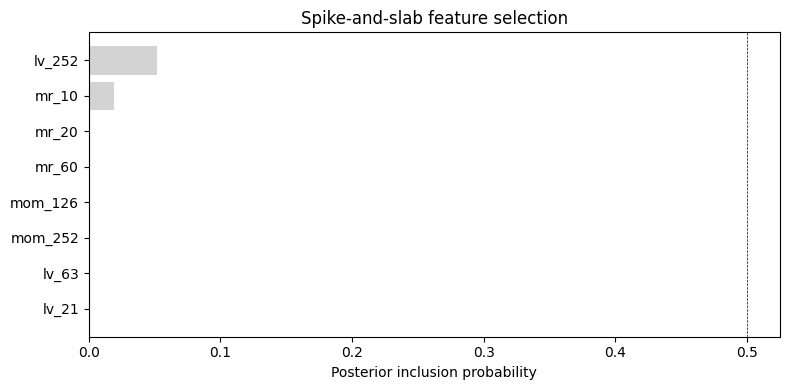

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
order = pip_df['feature'].tolist()
ax.barh(order, pip_df['PIP'], color=['steelblue' if v > 0.5 else 'lightgrey'
                                       for v in pip_df['PIP']])
ax.axvline(0.5, color='k', linewidth=0.5, linestyle='--')
ax.set_xlabel('Posterior inclusion probability')
ax.set_title('Spike-and-slab feature selection')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## Posterior Coefficient Distributions

For the selected features, plot the posterior of β. A coefficient whose posterior mass is bounded away from zero gives a stronger statement than a single OLS point estimate would.


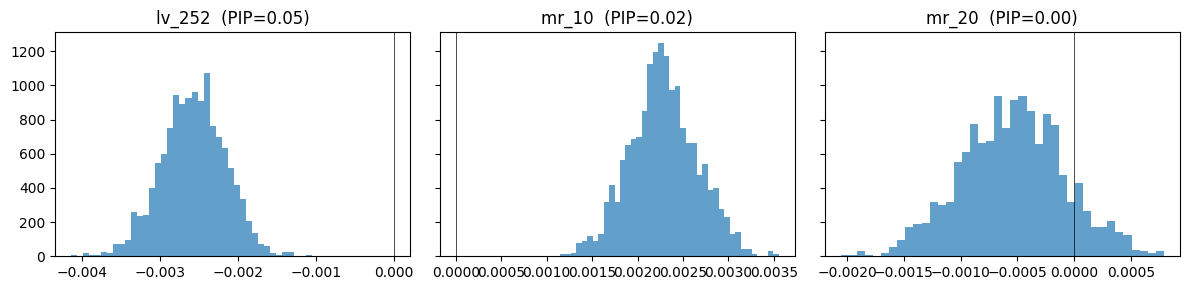

In [8]:
selected = pip_df[pip_df['PIP'] > 0.5]['feature'].tolist()
if len(selected) == 0:
    selected = pip_df.head(3)['feature'].tolist()

fig, axes = plt.subplots(1, len(selected), figsize=(4*len(selected), 3),
                          sharey=True)
if len(selected) == 1:
    axes = [axes]
for ax, feat in zip(axes, selected):
    j = feature_names.index(feat)
    ax.hist(samples_beta[:, j], bins=40, density=True, alpha=0.7)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_title(f'{feat}  (PIP={pip[j]:.2f})')
plt.tight_layout()
plt.show()


## Interpretation

The posterior tells us which features earn their place after accounting for all the others. Features that score high PIP across multiple lookbacks of the same signal family are evidence that the family matters; features that score high PIP at a single lookback are evidence that the specific window matters.

Note the limitations. SSVS is sensitive to the choice of slab variance; values much larger than the data scale lead to underestimated PIPs, values too small inflate them. Also, our panel mixes many cross-sections with substantial cross-sectional dependence, so the effective sample size is smaller than n. A more rigorous treatment would use a hierarchical prior to share variance across cross-sections, or a block-correlated likelihood. The point here is to demonstrate the method on a tractable example, not to push it to the limit.
